# ReAct: Build Reasoning and Acting AI Agents with LangGraph

## What is ReAct?

**ReAct** stands for **Reasoning + Acting**. It's a framework that combines:

1. **Reasoning**: The agent thinks through problems step by step, maintaining an internal dialogue about what it needs to do.
2. **Acting**: The agent can use external tools (search engines, calculators, APIs) to gather information or perform actions.
3. **Observing**: The agent processes the results from its actions and incorporates them into its reasoning.

This creates a powerful loop: **Think → Act → Observe → Think → Act → ...**

In [35]:
import warnings 
warnings.filterwarnings('ignore')

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage, SystemMessage
from typing import (Annotated,Sequence,TypedDict)
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END, START
from IPython.display import Image, display
import os
import json

from dotenv import load_dotenv
load_dotenv()


True

In [10]:
model = ChatOpenAI(model="gpt-4o-mini")

## Web Search Tool

In [ ]:
# Initialize the Tavily search tool
search = TavilySearchResults()
# search = TavilySearchResults(max_results=2)

@tool
def search_tool(query: str):
    """
    Search the web for information using Tavily API.

    :param query: The search query string
    :return: Search results related to the query
    """
    return search.invoke(query)

In [6]:
# search_tool.invoke("What's the weather like in Tokyo today?")
search_tool.invoke({"query": "What's the weather like in Tokyo today?"})

[{'url': 'https://www.timeanddate.com/weather/japan/tokyo',
  'content': 'timeanddate.com\nFlag for Japan\n\n# Weather in Tokyo, Japan\n\nSunny.\n\nFeels Like: 53 °F  \nForecast: 64 / 40 °F  \nWind: 3 mph ↑ from North\n\n|  |  |\n --- |\n| Location: | Tokyo Heliport |\n| Current Time: | Feb 21, 2026 at 12:50:37 pm |\n| Latest Report: | Feb 21, 2026 at 12:00 pm |\n| Visibility: | 10 mi |\n| Pressure: | 30.07 "Hg |\n| Humidity: | 47% |\n| Dew Point: | 34 °F |\n\nLocation of Tokyo\nLocation\n\n## Upcoming 5 hours\n\n|  |  |  |  |  |  |\n ---  ---  --- |\n| Now | 1:00 pm | 2:00 pm | 3:00 pm | 4:00 pm | 5:00 pm |\n|  |  |  |  |  |  |\n| 54 °F | 56 °F | 58 °F | 58 °F | 58 °F | 55 °F |\n\nSee more hour-by-hour weather\n\n## Forecast for the next 48 hours [...] | Probability of Precipitation | 0% | 0% | 0% | 0% | 0% | 5% | 10% |\n| Amount of Rain | 0.00" | 0.00" | 0.00" | 0.00" | 0.00" | 0.00" | 0.01" |\n| Amount of Snow | 0.00" | 0.00" | 0.00" | 0.00" | 0.00" | 0.00" | 0.00" |\n|  |  |  |  | 

## Clothing Recommendation Tool

In [7]:
@tool
def recommend_clothing(weather: str) -> str:
    """
    Returns a clothing recommendation based on the provided weather description.

    This function examines the input string for specific keywords or temperature indicators 
    (e.g., "snow", "freezing", "rain", "85°F") to suggest appropriate attire. It handles 
    common weather conditions like snow, rain, heat, and cold by providing simple and practical 
    clothing advice.

    :param weather: A brief description of the weather (e.g., "Overcast, 64.9°F")
    :return: A string with clothing recommendations suitable for the weather
    """
    weather = weather.lower()
    if "snow" in weather or "freezing" in weather:
        return "Wear a heavy coat, gloves, and boots."
    elif "rain" in weather or "wet" in weather:
        return "Bring a raincoat and waterproof shoes."
    elif "hot" in weather or "85" in weather:
        return "T-shirt, shorts, and sunscreen recommended."
    elif "cold" in weather or "50" in weather:
        return "Wear a warm jacket or sweater."
    else:
        return "A light jacket should be fine."

## Creating the Tool Registry

In [ ]:
tools=[search_tool,recommend_clothing]

tools_by_name={tool.name:tool for tool in tools}

## Setting up model with tools

In [12]:
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", """
        You are a helpful AI assistant that thinks step-by-step and uses tools when needed.

        When responding to queries:
        1. First, think about what information you need
        2. Use available tools if you need current data or specific capabilities  
        3. Provide clear, helpful responses based on your reasoning and any tool results

        Always explain your thinking process to help users understand your approach.
    """),
    MessagesPlaceholder(variable_name="scratch_pad")
])

In [ ]:
model_react = chat_prompt | model.bind_tools(tools)

## Agent State

In [15]:
class AgentState(TypedDict):
    """The state of the agent."""

    # add_messages is a reducer - See https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers
    # Sequence[BaseMessage] --> list of Human,AI,Tool Messages
    # add_messages --> automatically handles adding new messages to the conversation(state). while executing a node
    messages: Annotated[Sequence[BaseMessage], add_messages]

**Note:** We could also use MessageGraph here, instead of StateGraph.

In StateGraph, we manually manage State like above. But for MessageGraph, it will be handled automatically.

`Check 2.reflection-agents.ipynb for MessageGraph`

### Demonstrating State Management

In [16]:
# Example conversation flow:
state: AgentState = {"messages": []}

# append a message using the reducer properly
state["messages"] = add_messages(state["messages"], [HumanMessage(content="Hi")])
print("After greeting:", state["messages"])

# add another message (e.g. a question)
state["messages"] = add_messages(state["messages"], [HumanMessage(content="Weather in NYC?")])
print("After question:", state)

After greeting: [HumanMessage(content='Hi', id='5fe45a76-7faf-4687-9e55-e8d6695986d7')]
After question: {'messages': [HumanMessage(content='Hi', id='5fe45a76-7faf-4687-9e55-e8d6695986d7'), HumanMessage(content='Weather in NYC?', id='081adccb-fdd6-4264-8376-7052a5180090')]}


## Manual ReAct Execution (Understanding the Flow)

### Step 1: Initial Query Processing

In [ ]:
dummy_state: AgentState = {
        "messages": [HumanMessage( "What's the weather like in Zurich, and what should I wear based on the temperature?")]
    }

response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
# After running this cell: response is AI Response which includes information about tool to call

dummy_state["messages"] = add_messages(dummy_state["messages"],[response])

In [18]:
dummy_state["messages"]

[HumanMessage(content="What's the weather like in Zurich, and what should I wear based on the temperature?", id='316ad647-6723-44c2-b123-78b7ee0a0843'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_fYXbefZgakIAeIdBmDy17PMY', 'function': {'arguments': '{"query":"current weather in Zurich"}', 'name': 'search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 296, 'total_tokens': 313, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-d21917ab-0459-4c75-a743-52e576113ca8-0', tool_calls=[{'name': 'search_tool', 'args': {'query': 'current weather in Zurich'}, 'id': 'call_fYXbefZgakIAeIdBmDy17PMY', 'type': 'tool_call'}], usa

**What Happens Here:**

1. The user asks a complex question requiring current data.
2. The model analyzes the query and realizes it needs to search for weather information.
3. The model generates a tool call for the search.


### Step 2: Tool Execution

In [24]:
tool_call = response.tool_calls[-1] # get last tool_call
print("Tool call:", tool_call)

tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
tool_result

Tool call: {'name': 'search_tool', 'args': {'query': 'current weather in Zurich'}, 'id': 'call_fYXbefZgakIAeIdBmDy17PMY', 'type': 'tool_call'}


[{'url': 'https://www.timeanddate.com/weather/switzerland/zurich',
  'content': 'timeanddate.com\nFlag for Switzerland\n\n# Weather in Zürich, Zurich, Switzerland\n\nQuite cool.\n\nFeels Like: 32 °F  \nForecast: 52 / 36 °F  \nWind: 20 mph ↑ from Southwest\n\n|  |  |\n --- |\n| Location: | Zurich-Kloten |\n| Current Time: | Feb 21, 2026 at 5:35:10 am |\n| Latest Report: | Feb 21, 2026 at 4:00 am |\n| Visibility: | N/A |\n| Pressure: | 30.33 "Hg |\n| Humidity: | 82% |\n| Dew Point: | 36 °F |\n\nLocation of Zürich\nLocation\n\n## Upcoming 5 hours\n\n|  |  |  |  |  |  |\n ---  ---  --- |\n| Now | 6:00 am | 7:00 am | 8:00 am | 9:00 am | 10:00 am |\n|  |  |  |  |  |  |\n| 41 °F | 40 °F | 40 °F | 40 °F | 41 °F | 42 °F |\n\nSee more hour-by-hour weather\n\n## Forecast for the next 48 hours [...] | Probability of Precipitation | 1% | 14% | 4% | 0% | 0% | 0% | 0% |\n| Amount of Rain | 0.00" | 0.07" | 0.01" | 0.00" | 0.00" | 0.00" | 0.00" |\n| Amount of Snow | 0.00" | 0.00" | 0.00" | 0.00" | 0.00

In [20]:
print("Tool result preview:", tool_result[0]['content'])

tool_message = ToolMessage(
    content=json.dumps(tool_result),
    name=tool_call["name"],
    tool_call_id=tool_call["id"]
)
dummy_state["messages"] = add_messages(dummy_state["messages"], [tool_message])

Tool result preview: timeanddate.com
Flag for Switzerland

# Weather in Zürich, Zurich, Switzerland

Quite cool.

Feels Like: 32 °F  
Forecast: 51 / 37 °F  
Wind: 20 mph ↑ from Southwest

|  |  |
 --- |
| Location: | Zurich-Kloten |
| Current Time: | Feb 21, 2026 at 5:24:14 am |
| Latest Report: | Feb 21, 2026 at 4:00 am |
| Visibility: | N/A |
| Pressure: | 30.33 "Hg |
| Humidity: | 82% |
| Dew Point: | 36 °F |

Location of Zürich
Location

## Upcoming 5 hours

|  |  |  |  |  |  |
 ---  ---  --- |
| Now | 6:00 am | 7:00 am | 8:00 am | 9:00 am | 10:00 am |
|  |  |  |  |  |  |
| 41 °F | 40 °F | 40 °F | 40 °F | 41 °F | 42 °F |

See more hour-by-hour weather

## Forecast for the next 48 hours [...] | Probability of Precipitation | 1% | 14% | 4% | 0% | 0% | 0% | 0% |
| Amount of Rain | 0.00" | 0.07" | 0.01" | 0.00" | 0.00" | 0.00" | 0.00" |
| Amount of Snow | 0.00" | 0.00" | 0.00" | 0.00" | 0.00" | 0.00" | 0.00" |
|  |  |  |  |  |  |  |  |
 ---  ---  ---  --- |
| \ Updated Saturday, Februa

**What Happens Here:**

1. Extract the tool call from the model's response.
2. Execute the tool using the specified arguments.
3. Create a ToolMessage containing the results.
4. Add the tool result to the conversation state.

In [23]:
dummy_state["messages"]

[HumanMessage(content="What's the weather like in Zurich, and what should I wear based on the temperature?", id='316ad647-6723-44c2-b123-78b7ee0a0843'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_fYXbefZgakIAeIdBmDy17PMY', 'function': {'arguments': '{"query":"current weather in Zurich"}', 'name': 'search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 296, 'total_tokens': 313, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-d21917ab-0459-4c75-a743-52e576113ca8-0', tool_calls=[{'name': 'search_tool', 'args': {'query': 'current weather in Zurich'}, 'id': 'call_fYXbefZgakIAeIdBmDy17PMY', 'type': 'tool_call'}], usa

### Step 3: Processing Results and Next Action

In [25]:
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
dummy_state['messages'] = add_messages(dummy_state['messages'], [response])

# check if the model wants to use another tool
if response.tool_calls:
    tool_call = response.tool_calls[0] # Extract first tool call reference
    tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
    tool_message = ToolMessage(
        content=json.dumps(tool_result),
        name=tool_call["name"],
        tool_call_id=tool_call["id"]
    )
    dummy_state['messages'] = add_messages(dummy_state['messages'], [tool_message])

In [26]:
dummy_state['messages']

[HumanMessage(content="What's the weather like in Zurich, and what should I wear based on the temperature?", id='316ad647-6723-44c2-b123-78b7ee0a0843'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_fYXbefZgakIAeIdBmDy17PMY', 'function': {'arguments': '{"query":"current weather in Zurich"}', 'name': 'search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 296, 'total_tokens': 313, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_373a14eb6f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-d21917ab-0459-4c75-a743-52e576113ca8-0', tool_calls=[{'name': 'search_tool', 'args': {'query': 'current weather in Zurich'}, 'id': 'call_fYXbefZgakIAeIdBmDy17PMY', 'type': 'tool_call'}], usa

**What Happens Here:**

1. The model processes the search results.
2. It realizes it needs to use the clothing recommendation tool.
3. It extracts weather information and calls the clothing tool.
4. It receives clothing recommendations based on the weather data.

### Step 4: Final Response Generation

In [27]:
response = model_react.invoke({"scratch_pad": dummy_state["messages"]})
print("Final response generated:", response.content is not None)
print("More tools needed:", bool(response.tool_calls))

Final response generated: True
More tools needed: False


In [28]:
response.content

'The current weather in Zurich is quite cool, with a temperature of about 41°F (approximately 5°C). It feels colder, around 32°F due to the wind, and there is light rain expected.\n\n### Clothing Recommendations:\nGiven these conditions, it’s advisable to wear a raincoat and waterproof shoes to keep dry and warm. Additionally, consider layering with warm clothing underneath, such as a sweater or long-sleeved shirt, to stay comfortable.\n\nIf you have any more questions or need further assistance, feel free to ask!'

**What Happens Here:**
1. The model has all necessary information.
2. It synthesizes weather data and clothing recommendations.
3. It generates a comprehensive response to the user.
4. No more tool calls needed—the reasoning cycle is complete.


## Automating ReAct with Graphs

### Tool Execution Node

In [29]:
def tool_node(state: AgentState):
    """Execute all tool calls from the last message in the state."""
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}

**Function Purpose:**
- Automatically execute all tool calls from the model
- Handle multiple simultaneous tool calls
- Return properly formatted tool messages


### Model Invocation Node

In [30]:
def call_model(state: AgentState):
    """Invoke the model with the current conversation state."""
    response = model_react.invoke({"scratch_pad": state["messages"]})
    return {"messages": [response]}

**Function Purpose:**
- Call the ReAct-enabled model
- Pass the full conversation context
- Return the model's response (which may include tool calls)

### Decision Logic

In [31]:
def should_continue(state: AgentState):
    """Determine whether to continue with tool use or end the conversation."""
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

## Constructing the State Graph

In [33]:
# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# workflow.add_edge(START, agent)
workflow.set_entry_point("agent") # Set entry point
workflow.add_conditional_edges("agent",should_continue,{ "continue": "tools","end": END }) # If tools needed, go to tools node # If done, end the conversation
workflow.add_edge("tools", "agent")  # After tools, always go back to agent

# Compile the graph
graph = workflow.compile()

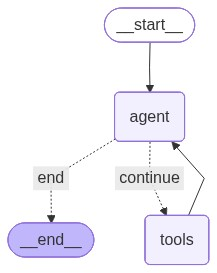

In [42]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Running the Complete ReAct Agent

In [ ]:
def print_stream(stream):
    """Helper function for formatting the stream nicely."""
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print() # a convenience method (from LangChain / LangGraph message objects) to prints the message in a clean format

inputs = {"messages": [HumanMessage(content="What's the weather like in Zurich, and what should I wear based on the temperature?")]}

print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

What's the weather like in Zurich, and what should I wear based on the temperature?
================================== Ai Message ==================================
Tool Calls:
  search_tool (call_sDXrZOKWQBfcwOnJACoP9JZN)
 Call ID: call_sDXrZOKWQBfcwOnJACoP9JZN
  Args:
    query: current weather in Zurich
================================= Tool Message =================================
Name: search_tool

[{"url": "https://www.weather25.com/europe/switzerland/zurich?page=month&month=February", "content": "Zurich is going to experience quite a number of days of snow during February. It\u2019s the perfect time to build snowmen, drink hot cocoa, and have a snowball fight. Just remember to wear a warm scarf and a pair of mittens!\n\nOur weather forecast can give you a great sense of what weather to expect in Zurich in February 2026.\n\nIf you\u2019re planning to visit Zurich in the near future, we highly recom

**About above execution:**
1. **User Query**: Passed User query to ReAct Agent
2. **Initial Reasoning**: Agent analyzes the query.
3. **Tool Call 1**: Searches for Zurich weather.
4. **Tool Result Processing**: Agent examines weather data.
5. **Tool Call 2**: Gets clothing recommendations.
6. **Final Synthesis**: Agent combines all information into a helpful response.


### The Complete ReAct Cycle

The final execution demonstrates the full ReAct pattern:

1. **Reasoning**: "I need current weather data for Zurich".
2. **Acting**: Calls search_tool("Zurich weather today").
3. **Observing**: Processes search results, extracts temperature.
4. **Reasoning**: "Now I need clothing recommendations for this temperature".
5. **Acting**: Calls recommend_clothing("temperature from search").
6. **Observing**: Gets clothing suggestions.
7. **Reasoning**: "I can now provide a complete answer".
8. **Final Response**: Synthesizes weather info and clothing recommendations.


---

## MORE TOOLS

### Build a Calculator Tool

In [ ]:
import math
from langchain.tools import tool

# Allowed names (whitelist)
SAFE_GLOBALS = {
    "__builtins__": None  # Disable built-ins completely
}

SAFE_LOCALS = {
    "sqrt": math.sqrt,
    "sin": math.sin,
    "cos": math.cos,
    "tan": math.tan,
    "log": math.log,
    "exp": math.exp,
    "pi": math.pi,
    "e": math.e,
    "abs": abs,
    "round": round,
    "pow": pow,
}


@tool
def calculator_tool(expression: str) -> str:
    """
    Safely evaluate mathematical expressions using eval.
    
    :param expression: A mathematical expression as a string
    :return: The result of the calculation
    """
    try:
        result = eval(expression, SAFE_GLOBALS, SAFE_LOCALS) # Instead of eval, we could also use "ast.literal_eval" for simple expressions
        return str(result)
    except Exception as e:
        return f"Error: {str(e)}"

In [47]:
print(calculator_tool.invoke("2 + 3 * 4"))
print(calculator_tool.invoke("sqrt(144)"))
print(calculator_tool.invoke("15/100 * 250 + sqrt(144)"))

14
12.0
49.5


### Create a News Summary Tool

In [ ]:
from langchain.tools import tool
from langchain.chat_models import ChatOpenAI
from langchain.prompts import ChatPromptTemplate

# Initialize LLM
llm = ChatOpenAI(model="gpt-4o-mini")

prompt = ChatPromptTemplate.from_messages([
        ("system",
         """You are a professional news analyst.
            Extract and summarize the top 3 news articles.

            For each article provide:
            1. Headline
            2. Date (if available)
            3. 3–5 main bullet points

            Format clearly and professionally.
            If information is missing, state 'Not specified'.
        """),
        ("human", "{news_content}")
    ])
    
chain = prompt | llm

@tool
def news_summarizer_tool(news_content: str) -> str:
    """
    Summarize news articles from search results.
    
    :param news_content: Raw news content or search results
    :return: A formatted summary of the news
    """
    
    response = chain.invoke({
        "news_content": news_content
    })
    
    return response.content

In [52]:
sample_news = """
AI Breakthrough in Healthcare
2026-02-20
Researchers developed a new AI model for early cancer detection. 
The model improves diagnosis accuracy by 30%. 
Hospitals are starting pilot programs.

New AI Chip Released
2026-02-19
A major tech company released a new AI accelerator chip. 
It promises faster model training and lower power consumption.
"""

res = news_summarizer_tool.invoke(sample_news)
print(res)

### Article 1
**Headline:** AI Breakthrough in Healthcare  
**Date:** 2026-02-20  
**Main Bullet Points:**
- Researchers have developed a new AI model specifically for early cancer detection.
- The model enhances diagnosis accuracy by 30%.
- Hospitals are initiating pilot programs to test the application of the new AI model.

### Article 2
**Headline:** New AI Chip Released  
**Date:** 2026-02-19  
**Main Bullet Points:**
- A major tech company has launched a new AI accelerator chip.
- The chip is designed to facilitate faster model training.
- It also claims to reduce power consumption compared to previous models.
